# Figure 2: Response of Ross Sea salinity and DSW/AABW to perturbations

In [1]:
%matplotlib inline
import xarray as xr
import numpy as np
import cosima_cookbook as cc
from dask.distributed import Client
import sys
sys.path.append(
    "/g/data/e14/cs6673/Ross_salinity/Python_scripts_published/") 
from Info_definitions import (
    path_data_published, path_plots, exptdict)

import matplotlib.pyplot as plt
import string

In [2]:
plt.rcParams['figure.dpi'] = 96
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["lines.linewidth"] = 1.5
plt.rcParams["lines.markersize"] = 3
plt.rcParams['hatch.color'] = 'k'
plt.rcParams["savefig.facecolor"] = 'white'

In [3]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/36147/status,
Dashboard: /proxy/36147/status,Workers: 7
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36257,Workers: 7
Dashboard: /proxy/36147/status,Total threads: 28
Started: Just now,Total memory: 251.19 GiB
Comm: tcp://127.0.0.1:41193,Total threads: 4
Dashboard: /proxy/43069/status,Memory: 35.88 GiB
Nanny: tcp://127.0.0.1:35989,


## Load data

In [4]:
ekeys = ['ctrl', 'wind_50_down_zonal', 'mw_50_down']
ds_salt = xr.open_dataset(
    path_data_published + 'Timeseries_salinity_Ross_Sea.nc')
ds_thick = xr.open_dataset(
    path_data_published + 'Timeseries_AABW_thickness_Ross_Sea.nc')
ds_swmt = xr.open_dataset(
    path_data_published + 'Surface_water_mass_transformation_Ross_Sea.nc')

## Plots

In [5]:
def Fig_2(ekeys):
    fig = plt.figure(figsize=(12, 12))
    gs = fig.add_gridspec(4, 2, height_ratios=[1.5, 1, .1, 1.8],
                          hspace=.14)
    ax0 = fig.add_subplot(gs[0, :])
    ax1 = fig.add_subplot(gs[1, :])
    ax2 = fig.add_subplot(gs[3, 0])
    ax3 = fig.add_subplot(gs[3, 1])
    axs = [ax0, ax1, ax2, ax3]

    for ekey in ekeys:
        e = exptdict[ekey]
        
        """ a) salinity """
        for area in ['TNB', 'DT']:
            if area == 'TNB':
                # 74.75°S–75.50°S and 163.00°E–166.00°E, 870-900 dbar
                name = 'Terra Nova\nBay'
                if ekey == 'ctrl':
                    ax0.text(.01, .75, name, transform=ax0.transAxes)
                k = 44  # depth index 44 is appr. at depth of obs
                lon_range = [-197, -194]
                lat_range = [-75.5, -74.75]
                linestyle = '-'
            elif area == 'DT':
                # 72.00°S and 72.67°S and 171.50°E and 174.50°E,
                # bottom 20 dbar
                name = 'Drygalski Trough'
                if ekey == 'ctrl':
                    ax0.text(.01, .4, name, transform=ax0.transAxes)
                k = 'bot'
                lon_range = [-188.5, -185.5]
                lat_range = [-72.67, -72]
                linestyle = '--'
            salt = ds_salt['salt_' + area + '_' + ekey]
            ax0.plot(salt.time, salt,
                     color=e['col'], label=e['expt_str'], linestyle=linestyle)

        """ b) AABW thickness """
        thickAABW = ds_thick['AABW_thickness_' + ekey]
        ax1.plot(thickAABW.time, thickAABW, marker='o', color=e['col'])

    handles, labels = ax0.get_legend_handles_labels()
    ax0.legend(handles[::2], labels[::2], ncol=len(ekeys),
                 loc='center', bbox_to_anchor=(0.5, 1.08))
    for p in np.arange(len(axs[:-2])):
        axs[p].set_xlim(0, len(thickAABW.time))
        if p == 0:
            axs[p].text(.01, .93, string.ascii_lowercase[p] + ') ',
                       fontweight='bold', transform=axs[p].transAxes)
        else:
            axs[p].text(.01, .89, string.ascii_lowercase[p] + ') ',
                       fontweight='bold', transform=axs[p].transAxes)

    ax1.set_xlabel('Model year')
    ax0.set_ylabel('Absolute salinity (g kg$^{-1}$)')
    ax1.set_ylabel('AABW thickness at\nCape Adare (m)', labelpad=7)


    """ c + d) SWMT """
    ekeys = ekeys[1:]
    
    # maximum SWMT of time mean
    swmt_ctrl = ds_swmt['swmt_ctrl']
    swmt_max = swmt_ctrl[swmt_ctrl.argmax('isopycnal_bins').values]
    # isopycnal bin corresponding to SWMT 75% and 25% below its maximum value
    swmt_sig_bin_75 = swmt_ctrl.isopycnal_bins.sel(
        isopycnal_bins=slice(swmt_max.isopycnal_bins, None)).where(
        swmt_ctrl <= swmt_max*.75).min('isopycnal_bins')
    swmt_sig_bin_25 = swmt_ctrl.isopycnal_bins.sel(
        isopycnal_bins=slice(swmt_max.isopycnal_bins, None)).where(
        swmt_ctrl <= swmt_max*.25).min('isopycnal_bins')
    
    for i, ekey in enumerate(ekeys):
        e = exptdict[ekey]
        var_all = ['swmt', 'swmt', 'swmt_ctrl_rho', 'swmt_ctrl_fluxes']
        label_all = [exptdict['ctrl']['expt_str'], e['expt_str'],
                     r'CONTROL $\rho_0$ + ' + e['expt_str'] + ' fluxes',
                     e['expt_str'] + r' $\rho_0$ + CONTROL fluxes']
        col_all = [exptdict['ctrl']['col'], e['col'], 'silver', 'gold']
        ls_all = ['-', '-', (0, (3, 4)), (0, (3, 4))]
        lw_all = [2, 2, 2.5, 2.5]
        for p, var in enumerate(var_all):
            if p == 0:
                axs[i+2].axhline(swmt_sig_bin_25, color='k', linewidth=.7)
                axs[i+2].axhline(swmt_sig_bin_75, color='k', linewidth=.7)
                swmt = swmt_ctrl
            else:
                if len(var) == 4:
                    swmt = ds_swmt['swmt_' + ekey]
                else:
                    swmt = ds_swmt['swmt_' + ekey + '_with' + var[4:]]
            swmt_DSW = swmt.sel(isopycnal_bins=slice(
                swmt_sig_bin_75, swmt_sig_bin_25)).mean('isopycnal_bins')
            if p < 2:
                axs[i+2].plot(
                    swmt_DSW, (swmt_sig_bin_25 + swmt_sig_bin_75)/2, 's',
                    color=col_all[p], markersize=6)
            axs[i+2].plot(
                swmt, swmt.isopycnal_bins, color=col_all[p],
                linestyle=ls_all[p], linewidth=lw_all[p], label=label_all[p])
            
        axs[i+2].set_ylim(28.2, 27.4)
        axs[i+2].set_xlim(0, 2.6)
        axs[i+2].set_title(
            string.ascii_lowercase[i+2] + ') ' + e['expt_str'],
            loc='left', fontweight='bold')
    
        axs[i+2].legend(loc='upper right')
        axs[i+2].set_xlabel('Surface water mass transformation (Sv)')
    ax2.set_ylabel('Potential density $\sigma_0\,$(kg$\,$m$^{-3}$)',
                   labelpad=15)
    ax3.set_ylabel('Potential density $\sigma_0\,$(kg$\,$m$^{-3}$)')
    
    plt.savefig(path_plots + 'Fig2.png', dpi=300, bbox_inches="tight")
    plt.show()

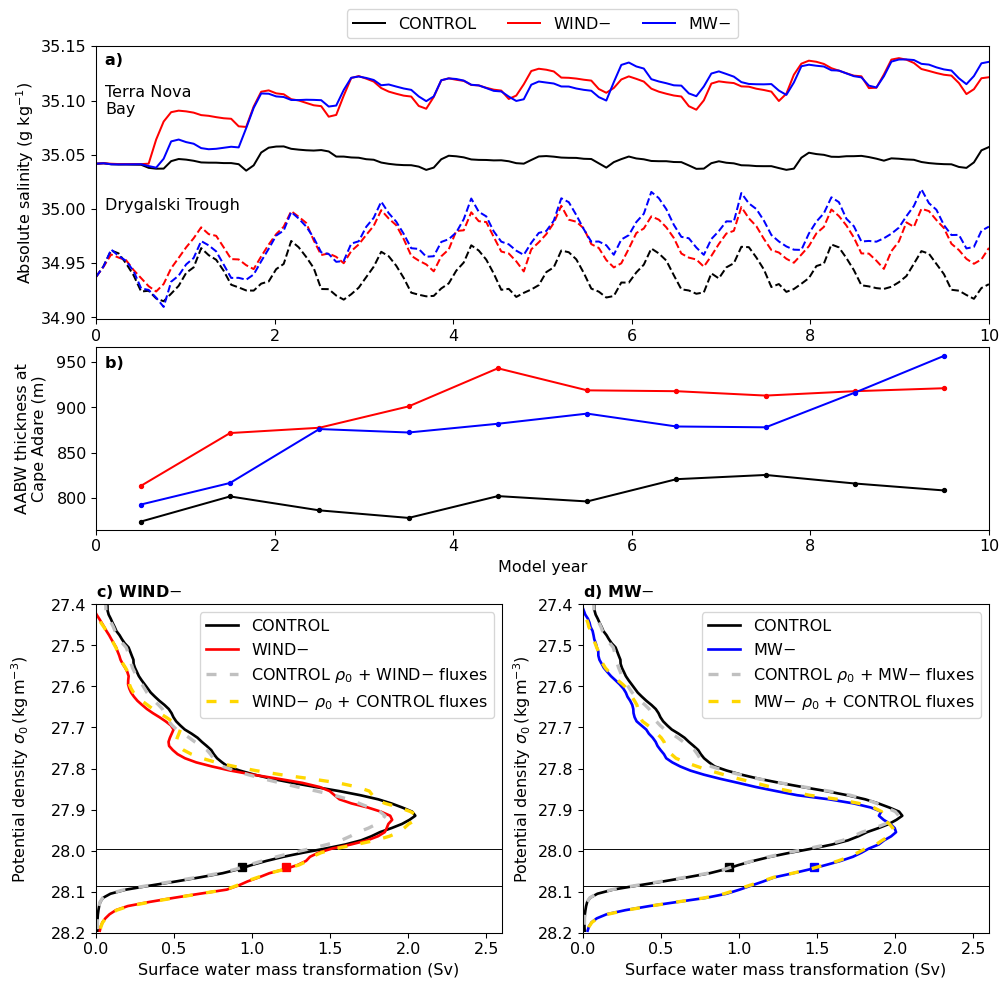

In [6]:
Fig_2(ekeys)

In [7]:
time_slice = slice(5, 10)

"""Salinity"""
for area in ['TNB', 'DT']:
    if area == 'TNB':
        # 74.75°S–75.50°S and 163.00°E–166.00°E, 870-900 dbar
        name = 'Terra Nova Bay'
        k = 44  # depth index 44 is appr. at depth of obs
        lon_range = [-197, -194]
        lat_range = [-75.5, -74.75]
        linestyle = '-'
    elif area == 'DT':
        # 72.00°S and 72.67°S and 171.50°E and 174.50°E, bottom 20 dbar
        name = 'Drygalski Trough'
        k = 'bot'
        lon_range = [-188.5, -185.5]
        lat_range = [-72.67, -72]
        linestyle = '--'
    print('')
    print('Mean salinity in ' + name + ' in years 6-10')

    for ekey in ekeys:
        salt = ds_salt['salt_' + area + '_' + ekey].sel(
            time=time_slice).mean('time').values
        if ekey == 'ctrl':
            salt_ctrl = salt
            print(ekey, ':', np.round(salt_ctrl, 3), ' g/kg')
        else:
            print(ekey, ':', np.round(salt, 3), ' g/kg (+',
                  np.round((salt-salt_ctrl), 3), 'g/kg)')

print('')
print('AABW thickness at Cape Adare in years 6-10')
rho_AABW = 27.86
for ekey in ekeys:
    thickAABW = ds_thick['AABW_thickness_' + ekey].sel(
        time=time_slice).mean('time')
    print(ekey, ':', np.int(thickAABW), 'm')


print('')
print('Mean SWMT in years 6-10')
for ekey in ekeys:
    e = exptdict[ekey]
    if ekey == 'ctrl':
        # maximum SWMT of time mean
        swmt_ctrl = ds_swmt['swmt_ctrl']
        swmt_max = swmt_ctrl[swmt_ctrl.argmax('isopycnal_bins').values]
        # isopycnal bin corresponding to SWMT 75% and 25% below its maximum value
        swmt_sig_bin_75 = swmt_ctrl.isopycnal_bins.sel(
            isopycnal_bins=slice(swmt_max.isopycnal_bins, None)).where(
            swmt_ctrl <= swmt_max*.75).min('isopycnal_bins')
        swmt_sig_bin_25 = swmt_ctrl.isopycnal_bins.sel(
            isopycnal_bins=slice(swmt_max.isopycnal_bins, None)).where(
            swmt_ctrl <= swmt_max*.25).min('isopycnal_bins')

    swmt = ds_swmt['swmt_' + ekey].sel(isopycnal_bins=slice(
        swmt_sig_bin_75, swmt_sig_bin_25)).mean('isopycnal_bins')
    if ekey == 'ctrl':
        swmt_ctrl = swmt.values
        print(ekey, ':', np.round(swmt_ctrl, 2), ' Sv')
    else:
        print(ekey, ':', np.round(swmt.values, 2), ' Sv (+',
              np.round((swmt.values-swmt_ctrl)/swmt_ctrl*100, 1), '%)')


Mean salinity in Terra Nova Bay in years 6-10
ctrl : 35.044  g/kg
wind_50_down_zonal : 35.118  g/kg (+ 0.074 g/kg)
mw_50_down : 35.121  g/kg (+ 0.077 g/kg)

Mean salinity in Drygalski Trough in years 6-10
ctrl : 34.94  g/kg
wind_50_down_zonal : 34.972  g/kg (+ 0.032 g/kg)
mw_50_down : 34.984  g/kg (+ 0.045 g/kg)

AABW thickness at Cape Adare in years 6-10
ctrl : 813 m
wind_50_down_zonal : 917 m
mw_50_down : 904 m

Mean SWMT in years 6-10
ctrl : 0.93  Sv
wind_50_down_zonal : 1.22  Sv (+ 30.5 %)
mw_50_down : 1.48  Sv (+ 58.6 %)
